# 2. Which branch of the revenue tree carries the Rs 23,00,000 fall: customers, how often they buy, or what each order is worth?

**Week 1, Tuesday. Chapter 2 of 6.** Chapter 1 found the drop real on matched windows: between two closed quarters of 13 weeks each,
revenue fell from Rs 2,10,00,000 to Rs 1,87,00,000, a fall of Rs 23,00,000 and 11.0 percent, and
Marketing's 25.9 percent had compared 11 weeks with 13. This chapter takes the fall apart along the
revenue tree, which writes revenue as customers x orders per customer x revenue per order; each of
the three factors is a leaf of the tree. Chapter 1's tool added rupees up by quarter; this chapter
grows it to count customers and orders per customer, puts rupees on each branch, and opens the price
branch, where Marketing's monsoon discount plan lives.

> **The client asks.** "Are we losing customers, or are the ones we have buying less? Marketing
> says more customers. Prove it or disprove it."
>
> Meera Raghavan, CEO, Kalpa Retail

**Who needs the answer.** Meera Raghavan, the CEO, decides which owner gets the problem. Marketing owns customers, the owners
of the membership tier and of the product range own how often customers buy, merchandising owns the
basket, and Finance with Marketing owns price. A wrong split sends crores to the wrong owner for a
quarter, and Marketing's Rs 12 crore to a branch that may not have moved.

**The questions on the way.**

1. Which of four ways should split the fall between the branches?
2. Did the number of customers fall?
3. Which leaf of the tree moved against Kalpa?
4. How many rupees does each branch carry, one leaf at a time?
5. What share of orders carried a discount, once a missing discount counts as unknown?
6. Does a split that chooses no order put the fall on the same branch?

**The need.** Meera's tree has four branches: customers, how often they buy, basket, and price, and
each has a price tag. Customers cost acquisition spend; how often they buy costs retention work on
people already won; basket belongs to merchandising, the team that picks the range and the pack
sizes; price and discounts trade margin for volume, giving up some profit on each order to sell more
of them. The metric at stake is the rupees each branch carries of the Rs 23,00,000 fall, and the
decision riding on it is which owner gets the problem, and whether Marketing's Rs 12 crore is aimed
at a branch that moved.

**Who else faces this.** Blinkit, the quick-commerce app, reports its orders and its net average
order value, the average order after discounts, side by side, so its net order value can be read as
the two branches of this tree: in the fourth quarter of FY26 it reported 273.9 million orders at
Rs 525 each, about Rs 14,386 crore (Eternal, shareholders' letter, 28 April 2026, checked
30 Sep 2026). Walmart splits the growth of its U.S. comparable sales the same way every quarter: in
the quarter ended 31 July 2026, comparable sales excluding fuel rose 2.6 percent, made of transactions
up 1.5 percent and average ticket, the spend per transaction, up 1.1 percent (Walmart earnings
release, second quarter of fiscal 2027, checked 30 Sep 2026). The question each answers is Meera's:
did more visits move the number, or bigger baskets?

Kavya Nair, the team's senior analyst, reviews every number before it leaves.

> **Kavya's review of chapter 1.** "Good: you said both windows before you said a percentage. Now
> stop describing the fall and start taking it apart."

**Setup.** The first lines find the programme's helper, `c2kit`, and import it as `kit`. The export
loads as a list of dictionaries, one per booked order, and chapter 1's accumulator, keyed by quarter,
now holds each quarter's orders themselves.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
by_quarter = {"Q1": [], "Q2": []}           # chapter 1's accumulator, now holding the orders themselves
for order in ORDERS:
    by_quarter[order["quarter"]].append(order)
print(len(by_quarter["Q1"]), "orders in Q1 and", len(by_quarter["Q2"]), "in Q2")

114 orders in Q1 and 86 in Q2


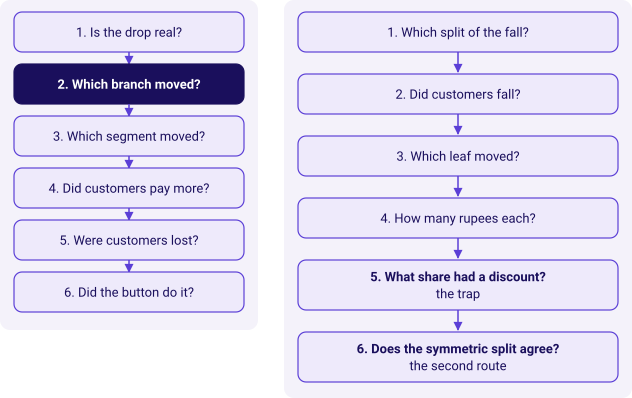

In [2]:
kit.side_by_side(
    kit.ladder(['Is the drop real?', 'Which branch moved?', 'Which segment moved?', 'Did customers pay more?', 'Were customers lost?', 'Did the button do it?'], lit=1, show=False),
    kit.vflow(['1. Which split of the fall?', '2. Did customers fall?', '3. Which leaf moved?', '4. How many rupees each?', '5. What share had a discount?\nthe trap', '6. Does the symmetric split agree?\nthe second route'], show=False),
)

## 1. Which of four ways should split the fall between the branches?

A team could split the fall across the branches in four ways.

| Option | How it splits | What it gives Meera |
|---|---|---|
| A. Each leaf's percentage change | Customers, orders per customer and revenue per order, Q1 against Q2 | Direction, and no rupees, since percentages multiply and do not add |
| B. A bridge in the tree's order | Change one leaf at a time, customers first, holding the rest at Q1 | Rupees per branch that add exactly to the fall, for the order chosen |
| C. A symmetric split | Share the fall in proportion to each leaf's logarithmic change | Rupees that do not depend on any order |
| D. Customer by customer | Each of the 69 customers' Q1 and Q2 orders side by side | Who moved, at 69 rows of reading before any total |

On this file each option is sized by the rupees it charges frequency, whether those rupees add to
the fall and depend on the order of the steps, and what Meera would have to read. The bridge is sized
twice, in the tree's order and reversed, since the order of the steps is where the choice bites.

Option,Frequency's rupees,Adds to the fall?,Depends on order?,What Meera reads
A. percentages only,none: percentages do not add,no,no,three percentages
"B. bridge, tree order","-Rs 51,57,895","yes, exactly",yes,three rupee steps
"B. bridge, order reversed","-Rs 60,88,372","yes, exactly",yes,three rupee steps
C. symmetric split,"-Rs 55,88,480","yes, exactly",no,three rupee figures and a logarithm
D. customer by customer,a total only after 69 rows,after summing,no,69 rows


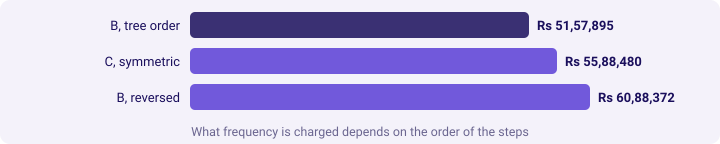

In [3]:
import math

def leaves(rows):
    seen = {}
    revenue = 0
    for order in rows:
        seen[order["customer_id"]] = True
        revenue += order["amount"]
    return len(seen), len(rows) / len(seen), revenue / len(rows), revenue

c1, f1, v1, r1 = leaves(by_quarter["Q1"])
c2, f2, v2, r2 = leaves(by_quarter["Q2"])
b_freq = c2 * (f2 - f1) * v1                       # B: frequency moved before order value
rev_freq = c2 * (f2 - f1) * v2                     # B reversed: order value first, frequency second
log_mean = (r2 - r1) / math.log(r2 / r1)
c_freq = log_mean * math.log(f2 / f1)              # C: symmetric
kit.table(["Option", "Frequency's rupees", "Adds to the fall?", "Depends on order?", "What Meera reads"],
          [("A. percentages only", "none: percentages do not add", "no", "no", "three percentages"),
           ("B. bridge, tree order", kit.rupees(round(b_freq)), "yes, exactly", "yes", "three rupee steps"),
           ("B. bridge, order reversed", kit.rupees(round(rev_freq)), "yes, exactly", "yes", "three rupee steps"),
           ("C. symmetric split", kit.rupees(round(c_freq)), "yes, exactly", "no", "three rupee figures and a logarithm"),
           ("D. customer by customer", "a total only after 69 rows", "after summing", "no", "69 rows")],
          caption="Sizing the split on the Rs 23,00,000 fall")
kit.bars([("B, tree order", round(-b_freq)), ("C, symmetric", round(-c_freq)), ("B, reversed", round(-rev_freq))],
         fmt=kit.rupees, lit=[0], title="What frequency is charged depends on the order of the steps")
kit.check("the three rupee figures sit within Rs 10 lakh of each other", abs(rev_freq - b_freq) < 1000000,
          kit.rupees(round(abs(rev_freq - b_freq))))

On this file the bridge in the tree's order charges frequency Rs 51,57,895, the same bridge with its
order reversed Rs 60,88,372, and the symmetric split Rs 55,88,480.

**The best-fit call.** Option B, the bridge in the tree's order, because its rupees add exactly to
the fall, a CEO can follow it one step at a time, and in every order frequency carries the fall, so
the choice of order changes the size and never the decision. Write the order beside the bridge.
**The fact that would change the call:** if Finance will rebuild the split every month and two
branches keep moving together, option C removes the argument about order; if Meera asks which
customers slowed, option D is the one that names them, and chapter 5 comes back to it.

## 2. Did the number of customers fall?

Marketing's claim is about the first branch, so it is counted first. A dictionary per quarter maps
each customer id to the orders that customer placed. `.get(cid, 0)` reads the count so far and
supplies 0 when the id has not appeared yet, and that default is right for a reason worth writing
down: a customer not seen yet in the quarter has placed no orders in it so far.

**Predict before you run.** How did the number of distinct customers move from Q1 to Q2? a) it fell;
b) it held; c) it rose, as Marketing says; d) it cannot be told without the segments.

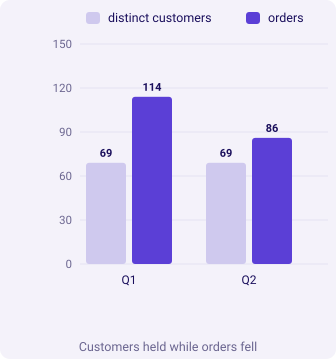

In [4]:
orders_by_customer = {"Q1": {}, "Q2": {}}      # quarter -> {customer_id: orders placed}
for q in by_quarter:
    for order in by_quarter[q]:
        cid = order["customer_id"]
        # default: a customer not seen yet in this quarter has placed zero orders in it so far
        orders_by_customer[q][cid] = orders_by_customer[q].get(cid, 0) + 1

customers = {q: len(orders_by_customer[q]) for q in by_quarter}
orders = {q: len(by_quarter[q]) for q in by_quarter}
kit.columns(["Q1", "Q2"], [("distinct customers", [customers["Q1"], customers["Q2"]]),
                           ("orders", [orders["Q1"], orders["Q2"]])],
            title="Customers held while orders fell")
kit.check("customers held at 69 in both quarters", customers["Q1"] == customers["Q2"] == 69,
          f'{customers["Q1"]} and {customers["Q2"]}')
kit.check("the per-customer counts add back to each quarter's orders",
          all(sum(orders_by_customer[q].values()) == orders[q] for q in by_quarter))

**What happened.** The answer is b. Kalpa had 69 distinct customers in each quarter, so the count
does not support "more customers". Orders fell from 114 to 86 on the same count, which already points
at the second branch. Whether the 69 are the same people is a separate question, and chapter 5 asks it.

## 3. Which leaf of the tree moved against Kalpa?

The tree multiplies three leaves: customers, orders per customer, and revenue per order. Price and
basket fold into revenue per order today, because the file has no order lines.

**Predict before you run.** Which leaf moved against Kalpa? a) customers; b) orders per customer;
c) revenue per order; d) all three fell a little.

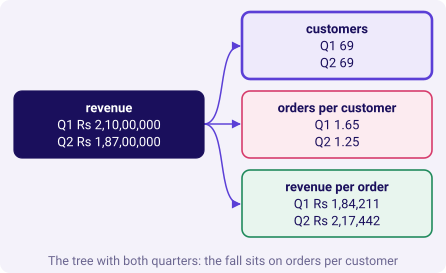

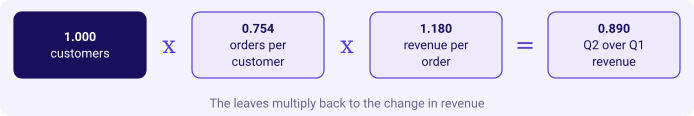

In [5]:
revenue = {"Q1": r1, "Q2": r2}
opc = {"Q1": f1, "Q2": f2}          # orders per customer
rpo = {"Q1": v1, "Q2": v2}          # revenue per order
kit.driver_tree({"label": "revenue", "note": f'Q1 {kit.rupees(r1)}\nQ2 {kit.rupees(r2)}', "kind": "lit", "children": [
    {"label": "customers", "note": f'Q1 {customers["Q1"]}\nQ2 {customers["Q2"]}', "kind": "known"},
    {"label": "orders per customer", "note": f'Q1 {f1:.2f}\nQ2 {f2:.2f}', "kind": "bad"},
    {"label": "revenue per order", "note": f'Q1 {kit.rupees(round(v1))}\nQ2 {kit.rupees(round(v2))}', "kind": "good"}]},
    title="The tree with both quarters: the fall sits on orders per customer", width_per=190)
ratio_c, ratio_f, ratio_v = c2 / c1, f2 / f1, v2 / v1
kit.equation([f"{ratio_c:.3f}\ncustomers", "x", f"{ratio_f:.3f}\norders per customer", "x",
              f"{ratio_v:.3f}\nrevenue per order", "=", f"{ratio_c * ratio_f * ratio_v:.3f}\nQ2 over Q1 revenue"],
             title="The leaves multiply back to the change in revenue")
kit.check("the three ratios multiply to Q2 over Q1 revenue", abs(ratio_c * ratio_f * ratio_v - r2 / r1) < 1e-9,
          f"{ratio_c * ratio_f * ratio_v:.3f}")
kit.check("orders per customer fell 24.6 percent and revenue per order rose 18.0",
          (round((ratio_f - 1) * 100, 1), round((ratio_v - 1) * 100, 1)) == (-24.6, 18.0))

**What happened.** The answer is b. Orders per customer fell from 1.65 to 1.25, down 24.6 percent,
while revenue per order rose 18.0 percent, from Rs 1,84,211 to Rs 2,17,442. The same count of
customers placed fewer orders, and the orders they placed were larger on average. Adding the two
percentages would say minus 6.6 percent; multiplying says 0.754 times 1.180, which is 0.890, the
11.0 percent fall. Chapter 4 asks why the orders got larger.

## 4. How many rupees does each branch carry, one leaf at a time?

This builds option B. The bridge changes one leaf at a time in the order of the tree: first
customers, holding the other two at Q1; then orders per customer; then revenue per order.

**Predict before you run.** How many rupees does the fall in orders per customer take away?
a) Rs 23,00,000; b) Rs 51,57,895; c) Rs 28,57,895; d) nothing, because customers held.

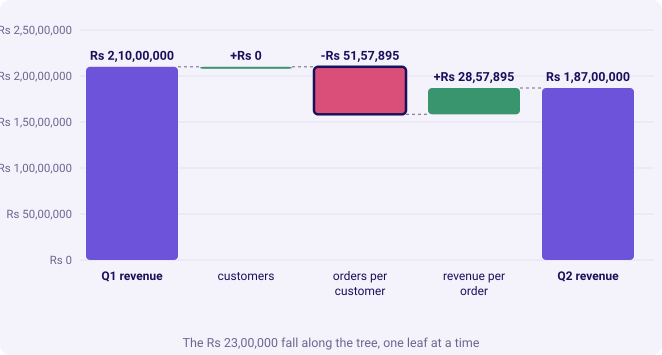

In [6]:
move_customers = (c2 - c1) * f1 * v1
move_frequency = c2 * (f2 - f1) * v1
move_order_value = c2 * f2 * (v2 - v1)
kit.bridge(("Q1 revenue", r1),
           [("customers", round(move_customers)), ("orders per customer", round(move_frequency)),
            ("revenue per order", round(move_order_value))],
           end_label="Q2 revenue", lit=[1], title="The Rs 23,00,000 fall along the tree, one leaf at a time")
kit.check("the bridge lands on Q2 revenue", abs(r1 + move_customers + move_frequency + move_order_value - r2) < 1,
          kit.rupees(r2))
kit.check("the customers move is zero", move_customers == 0)

**What happened.** The answer is b. Holding customers and order value at Q1, the fall in orders per
customer takes away Rs 51,57,895, and larger orders give back Rs 28,57,895. The customer branch
contributes nothing, so Marketing's case for acquisition has no rupees behind it on this file.

## 5. What share of orders carried a discount, once a missing discount counts as unknown?

Meera's fourth branch is price, and Marketing's monsoon plan starts from one number on it: the share
of orders that carry a discount. If half the orders go without one, they want the discount extended
to the other half. The export carries a `discount` field in rupees, so the first attempt counts the
orders where it is above zero.

In [7]:
with kit.expect_error() as err:
    with_discount = 0
    for order in ORDERS:
        if order["discount"] > 0:
            with_discount += 1
kit.check("the loop stopped on a missing key", err.name == "KeyError", f"{err.name}: {err.message}")

That is a runtime error, and it takes two minutes: some records carry no `discount` key at all, and
indexing a dictionary with a key it lacks raises `KeyError`. A `try` and `except KeyError` around the
line would also get past it. What a missing discount means decides the number.

**Predict before you run.** A hurried analyst reads every missing discount as zero. What share of
Q2's 86 orders will carry a discount? a) about a quarter; b) about half; c) about seven in ten;
d) every order.

**The plausible wrong answer.** `.get("discount", 0)` makes the error go away and gives a number.

In [8]:
with_disc = {"Q1": 0, "Q2": 0}
for q in by_quarter:
    for order in by_quarter[q]:
        if order.get("discount", 0) > 0:          # the hurried default: missing becomes zero
            with_disc[q] += 1
as_zero_share = {q: with_disc[q] / orders[q] * 100 for q in by_quarter}
kit.stats([(f'{as_zero_share["Q1"]:.1f}%', "orders with a discount, Q1", "missing read as zero"),
           (f'{as_zero_share["Q2"]:.1f}%', "orders with a discount, Q2", "missing read as zero"),
           (f'{orders["Q2"] - with_disc["Q2"]} of {orders["Q2"]}', "Q2 orders read as no discount", "so, extend it to them?")])

**Why it is wrong.** The answer to the prediction is b, and it is the wrong number. The 43 Q2 orders
the hurried reading files under "no discount" are two different things: orders where someone
recorded Rs 0 off, and orders where nobody wrote the discount down at all. The second kind is
unknown, and a default of zero counts every one of them as an order that went without. The decision
it misleads is expensive: Marketing extends the monsoon discount to "the other half" of orders,
spending margin on orders that may already carry one.

The mechanism on three **invented** orders, one with Rs 100 off, one with Rs 0 off, and one with no
field at all:

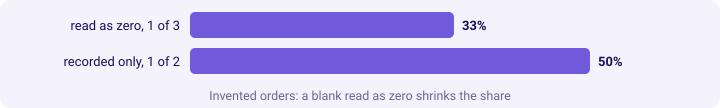

In [9]:
invented = [{"order_id": "INVENTED-1", "discount": 100},
            {"order_id": "INVENTED-2", "discount": 0},
            {"order_id": "INVENTED-3"}]                      # invented records, no discount field on the third
as_zero_with = sum(1 for o in invented if o.get("discount", 0) > 0)
recorded = [o for o in invented if "discount" in o]
recorded_with = sum(1 for o in recorded if o["discount"] > 0)
kit.bars([("read as zero, 1 of 3", round(as_zero_with / 3 * 100)), ("recorded only, 1 of 2", round(recorded_with / len(recorded) * 100))],
         fmt=lambda v: f"{v}%", title="Invented orders: a blank read as zero shrinks the share")
kit.check("on the invented orders, read-as-zero gives 33 percent and recorded-only 50 percent",
          (round(as_zero_with / 3 * 100), round(recorded_with / len(recorded) * 100)) == (33, 50))

**Your turn.** Count the Kalpa records that carry no `discount` field, in each quarter. Type these
lines into the empty cell below and run them, then say in one sentence how many of the orders the
hurried reading called "no discount" were never recorded:

```python
missing = {"Q1": 0, "Q2": 0}
for order in ORDERS:
    if "discount" not in order:
        missing[order["quarter"]] += 1
print(missing)
```

**The check.** Split the orders the hurried reading called "no discount" into the ones that record
Rs 0 and the ones with no field at all, and find the largest discount anyone recorded.

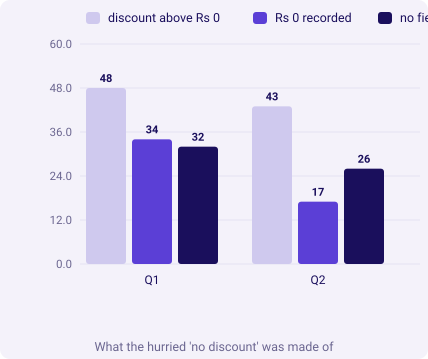

In [10]:
kinds = {q: {"above": 0, "zero": 0, "blank": 0} for q in by_quarter}
largest = 0
for q in by_quarter:
    for order in by_quarter[q]:
        if "discount" not in order:
            kinds[q]["blank"] += 1
        elif order["discount"] > 0:
            kinds[q]["above"] += 1
            largest = max(largest, order["discount"])
        else:
            kinds[q]["zero"] += 1
kit.columns(["Q1", "Q2"], [("discount above Rs 0", [kinds["Q1"]["above"], kinds["Q2"]["above"]]),
                           ("Rs 0 recorded", [kinds["Q1"]["zero"], kinds["Q2"]["zero"]]),
                           ("no field", [kinds["Q1"]["blank"], kinds["Q2"]["blank"]])],
            fmt=lambda v: f"{v}", title="What the hurried 'no discount' was made of")
kit.check("the three kinds add up to every order in each quarter", all(sum(kinds[q].values()) == orders[q] for q in kinds))
kit.check("Q2's 'no discount' orders are recorded zeros plus blanks",
          orders["Q2"] - with_disc["Q2"] == kinds["Q2"]["zero"] + kinds["Q2"]["blank"],
          f'{orders["Q2"] - with_disc["Q2"]} = {kinds["Q2"]["zero"]} + {kinds["Q2"]["blank"]}')
kit.check("the largest recorded discount is Rs 150", largest == 150, kit.rupees(largest))

**The fix.** Treat a blank as unknown. Write the rule where the next person will read it, report
the share over the orders that record the field, give the range the blanks allow, and bound the
branch in rupees: the largest recorded discount is Rs 150, so even if every one of Q2's 86 orders had
carried Rs 150 off, the branch could hold at most Rs 12,900 against a fall of Rs 23,00,000.

Share of orders with a discount,Q1,Q2
hurried: blanks read as zero,42.1%,50.0%
over the orders that record the field,58.5% of 82,71.7% of 60
"range over all orders, blanks unknown",42.1% to 70.2%,50.0% to 80.2%


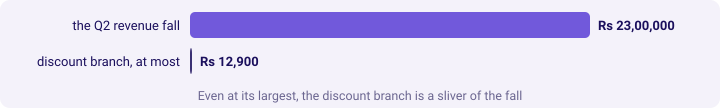

The rule, written down: absent means not recorded; reported separately; never counted as zero


In [11]:
DISCOUNT_RULE = "absent means not recorded; reported separately; never counted as zero"
recorded_n = {q: kinds[q]["above"] + kinds[q]["zero"] for q in kinds}
share_recorded = {q: kinds[q]["above"] / recorded_n[q] * 100 for q in kinds}
share_top = {q: (kinds[q]["above"] + kinds[q]["blank"]) / orders[q] * 100 for q in kinds}
kit.table(["Share of orders with a discount", "Q1", "Q2"],
          [("hurried: blanks read as zero", f'{as_zero_share["Q1"]:.1f}%', f'{as_zero_share["Q2"]:.1f}%'),
           ("over the orders that record the field", f'{share_recorded["Q1"]:.1f}% of {recorded_n["Q1"]}', f'{share_recorded["Q2"]:.1f}% of {recorded_n["Q2"]}'),
           ("range over all orders, blanks unknown", f'{as_zero_share["Q1"]:.1f}% to {share_top["Q1"]:.1f}%', f'{as_zero_share["Q2"]:.1f}% to {share_top["Q2"]:.1f}%')],
          caption="The hurried share is the floor of the range, reported as the fact")
bound = orders["Q2"] * largest
kit.bars([("the Q2 revenue fall", r1 - r2), ("discount branch, at most", bound)],
         fmt=kit.rupees, lit=[1], title="Even at its largest, the discount branch is a sliver of the fall")
kit.check("where the field is recorded, 71.7 percent of Q2's orders carry a discount", round(share_recorded["Q2"], 1) == 71.7)
kit.check("the discount branch is under one percent of the fall", bound / (r1 - r2) < 0.01, f"{kit.rupees(bound)}")
print("The rule, written down:", DISCOUNT_RULE)

**What changed.** "Half of Q2's orders had no discount, extend it to them" became "where the field
is recorded, 71.7 percent of Q2's orders carried a discount; 17 of 86 are known to have had none, and
26 are unknown". The extension loses its premise until someone finds which system left those records
blank, and the whole branch is worth at most Rs 12,900, so discounts leave the list of causes.

## 6. Does a split that chooses no order put the fall on the same branch?

The bridge charged the part where two leaves moved together to whichever leaf moved second. The
second route splits the same fall a different way: each leaf takes a share in proportion to its
logarithmic change, so no order is chosen at all. It is an independent method, so if the bridge had
put the fall on the wrong branch, this split would say so. The rupees per branch will differ by that
joint part; the branch that carries the fall must not.

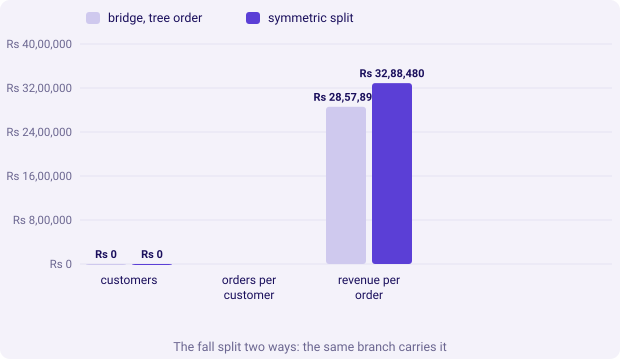

In [12]:
weight = (r2 - r1) / math.log(r2 / r1)          # the log-mean of the two quarters' revenue
symmetric = {"customers": weight * math.log(c2 / c1),
             "orders per customer": weight * math.log(f2 / f1),
             "revenue per order": weight * math.log(v2 / v1)}
bridge_moves = {"customers": move_customers, "orders per customer": move_frequency,
                "revenue per order": move_order_value}
kit.columns(list(symmetric), [("bridge, tree order", [round(bridge_moves[k]) for k in symmetric]),
                              ("symmetric split", [round(symmetric[k]) for k in symmetric])],
            fmt=kit.rupees, width=620, title="The fall split two ways: the same branch carries it")
kit.check("the symmetric split adds to the same fall", round(sum(symmetric.values())) == round(r2 - r1),
          kit.rupees(round(sum(symmetric.values()))))
kit.check("both routes charge the largest fall to orders per customer",
          min(symmetric, key=symmetric.get) == min(bridge_moves, key=bridge_moves.get) == "orders per customer")

The two routes put the fall on the same branch: the symmetric split charges frequency Rs 55,88,480,
which is Rs 4,30,585 more than the bridge, the joint part the bridge gave to the leaf that moved
second.

**When to switch.** Keep the bridge for Meera, with its order written beside it, because a CEO can
follow one leaf at a time. Switch to the symmetric split when two branches keep moving together and
someone else rebuilds the split every month, since then nobody argues about order.

> **Kavya's review.** "Meera asked two questions and you answered both with a count: customers held
> at 69, and the ones we have bought less often. Put the bridge in front of her with its order
> written beside it, and do not call the rise in order value good news until you know where it came
> from."

### In the interview: how do you split a revenue change, why does a rate need its denominator, and is a missing field a zero?

The tags mark how often a question comes up: [S] a staple asked everywhere, [F] frequent in GCC and product screens, [SV] a service-major screen opener, [D] a differentiator.

**[F] Revenue fell 11 percent; how do you split the change between customers, frequency and order
value?** "I write revenue as customers times orders per customer times revenue per order and compute
each leaf in both periods. The ratios multiply back to the revenue ratio, which proves the leaves are
consistent. To put rupees on each, I change one leaf at a time in the tree's order, holding the
others at the earlier period, so the moves add exactly to the total. On Kalpa's quarters that gave
customers nothing, frequency minus Rs 51,57,895 and order value plus Rs 28,57,895. I say that the
split depends on the order, and I keep the order fixed across reports." The interviewer is listening
for the multiplicative check and for rupees in place of percentages that do not add.

**[S] Why is a rate without a denominator meaningless?** "Because a rate is a count divided by
something over a window, and changing either of the other two changes the number. On invented
numbers, 120 orders in a quarter come to 1.20 orders per customer over the 100 customers who bought,
and to 0.60 over the 200 who hold an account. When someone quotes a rate, I ask what was counted,
what it was divided by and over which dates." The interviewer is listening for all three parts.

**[S] A field is missing on some records; do you fill it with zero?** "Only if zero is what missing
means, and someone has written down why. Usually missing means not recorded, which is unknown.
Filling with zero makes a total into a floor, and if the blank share changes between periods it
manufactures a trend. So I count the blanks, report them separately, compute on the recorded rows
and bound what the unknowns could do." The interviewer is listening for "unknown", the count of
blanks, and a bound.

**The design question. Which way do you split a revenue change for a CEO, and when would you
change it?** "A bridge in the tree's order, with the order written beside it, because it adds
exactly and a CEO can follow it. On Kalpa's quarters the order moves frequency's charge between
Rs 51.6 lakh and Rs 60.9 lakh and never changes which branch carries the fall. If the split is rebuilt
monthly by someone else, I switch to the symmetric split so nobody argues about order." The
interviewer is listening for a reason and the fact that would switch it.

### Depth: with three branches moving at once, can the order of the bridge change the verdict?

With three branches moving at once, a sequential bridge has six possible orders, and the symmetric
split still gives one answer, because the logarithms of the three ratios add exactly to the logarithm
of the revenue ratio (B. W. Ang, "The LMDI approach to decomposition analysis: a practical guide",
Energy Policy, 2005, checked through Crossref 29 Sep 2026). Try it: invent two quarters in which
customers move as well as the other two leaves, run the second route's split on them, and count how
many of the six bridge orders put the most rupees on the same branch.

References for the chapter:

- Python docs, built-in types, `dict.get`: https://docs.python.org/3/library/stdtypes.html (verified 29 Sep 2026)
- Corey Schafer, "Python Tutorial: Using Try/Except Blocks for Error Handling": https://www.youtube.com/watch?v=NIWwJbo-9_8 (verified 29 Sep 2026)

## So, which branch moved?

1. Of the four ways to split the fall, the bridge in the tree's order adds exactly and a CEO can follow it: it charges frequency Rs 51,57,895, against Rs 60,88,372 with the order reversed and Rs 55,88,480 symmetric.
2. The number of customers did not fall: 69 bought in each quarter, while orders fell from 114 to 86.
3. Orders per customer moved against Kalpa, 1.65 to 1.25, minus 24.6 percent, while revenue per order rose 18.0 percent; 1.000 x 0.754 x 1.180 is 0.890, the revenue ratio.
4. One leaf at a time, customers carry Rs 0, orders per customer minus Rs 51,57,895 and revenue per order plus Rs 28,57,895.
5. Read as zero, the blanks give 50.0 percent of Q2's orders a discount, with 43 "without"; of the 60 Q2 orders that record the field, 71.7 percent carried one, the 43 are 17 recorded zeros and 26 blanks, and the discount branch holds at most Rs 12,900.
6. A split that chooses no order puts the fall on the same branch: it charges frequency Rs 55,88,480, Rs 4,30,585 more than the bridge.

Orders per customer is the branch that moved: 1.65 to 1.25, carrying Rs 51,57,895 of the fall in the
tree's order. Customers held at 69, and discounts can carry at most Rs 12,900.

In [13]:
kit.check_summary()
print("Next, chapter 3. Which of the four customer segments carries the fall in orders per customer, "
      "measured the same way for every segment and quarter?")

Next, chapter 3. Which of the four customer segments carries the fall in orders per customer, measured the same way for every segment and quarter?
